## code to load in all datasets, create unique id's for them, then combine into single dataframe

List of datasets:
- SeaBASS (by region)
    - SB_chl_na.xlsx
- CalCOFI
    - calcofi_chl_qc.xlsx
- Gloria
    - NONE
- HOTS
    - hots_chl_qc.xlsx
- IOOS
    - ioos_chl_qc.xlsx(note:this is reduced to single day ones)
- WOD (1, 2, Ecomon)
    - wod_chl_na.xlsx
- BCO-DMO
    - bco_dmo_chl_qc.xlsx
- AquaMatch
    - aquamatch_chl_na.xlsx
- GLOBEC
    - globec_chl_qc.xlsx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
#ALL dataframes should have experiment, data_type (if possible), affiliations, investigators, contact, url
#IF the dataset does not have experiemnent, remove?? only once i concat

# Chlorophyll ID column and final concatination

In [2]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url','decision':'data_type_flag'})
seabass=seabass[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass['source']='SB'

In [3]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')
CalCOFI = CalCOFI.rename(columns={'identifier_product_doi':'DOI_url'})
CalCOFI['experiment']='CalCOFI'
CalCOFI['affiliations']='NOAA Fisheries, Scripps, CDFW'
CalCOFI['data_type']='bottle'

In [4]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')
HOTS = HOTS.rename(columns={'url':'DOI_url'})
HOTS['data_type']='bottle'

In [5]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc.xlsx')
IOOS = IOOS.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime'})
IOOS=IOOS[['datetime', 'lat', 'lon', 'chl', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment', 'HPLC', 'triplicate']]

In [6]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')
bco = bco.rename(columns={'url':'DOI_url'})

In [7]:
#wod doesn't always have experiment, but always has accession number i.e. NODC accession number so use that instead 
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')
wod=wod[['datetime', 'lat', 'lon', 'chl', 'depth', 'cruise','affiliations', 'investigators', 'HPLC', 'triplicate', 'accession number']]
wod['source'] = 'WOD'
wod['DOI_url'] = 'https://www.ncei.noaa.gov/access/world-ocean-database-select/dbsearch.html'
wod = wod.rename(columns={'accession number':'experiment'})

In [8]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')
aqua = aqua.rename(columns={'url':'DOI_url'})
aqua['experiment']='AquaMatch'

In [9]:
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')
globec = globec.rename(columns={'url':'DOI_url'})

In [10]:
dfs=[seabass,aqua,bco,CalCOFI,globec,HOTS,IOOS,wod]
all_chl = pd.concat(dfs).reset_index(drop=True)
all_chl = all_chl.dropna(subset=['chl', 'chl_a'], how='all')
all_chl = all_chl.dropna(subset=['datetime'], how='all') #if no datetime, remove

#so usually, HPLC chl is in the chl_a column. HOwever, sometimes, sometimes a project lables hplc chlorophyll as chl (NOT chl_a). 
#so, to keep it consistant, what i need to do is 1. IF HPLC is flagged as good (0), 2. if chl_a is empty, THEN populate with the value in chl.
#that way, we retain what the original data source says, but it makes the HPLC data more consistant. Sometimes chl and chl_a are both recorded also
all_chl.loc[(all_chl['HPLC']== 0) & (all_chl['chl_a'].isnull()), 'chl_a'] = all_chl['chl']

In [11]:
all_chl.isnull().sum()

datetime               0
lat                    0
lon                    0
chl                 5896
chl_a             794596
depth                  0
experiment             0
data_type         447870
station           497439
affiliations      175128
investigators     473985
contact           588084
cruise            473240
DOI_url            26094
HPLC                   0
triplicate             0
data_type_flag    588084
source                 0
cast              741775
dtype: int64

In [12]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_chl['temp_exp'] = all_chl['experiment'].str.replace('_', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('-', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(' ', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('(', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(')', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('[', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(']', '', regex=False)

In [13]:
all_chl['ID_code'] = all_chl['source'].astype(str) + '_' + all_chl['temp_exp'].astype(str) + '_' + all_chl['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_chl['lat'].astype(str) + '_' + all_chl['lon'].astype(str) +'_' + all_chl['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_chl['ID_code'] = all_chl['ID_code'] + '_' + all_chl.groupby('ID_code').cumcount().astype(str)

In [14]:
#a=all_chl.ID_code
#a.to_csv('chl_ids.txt', index=False, header=False, sep='\n')

In [15]:
all_chl=all_chl[['ID_code','datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source', 'cast']]

In [21]:
all_chl.to_excel('all_chl.xlsx', index = False)


### chlorophyll plots and visualization

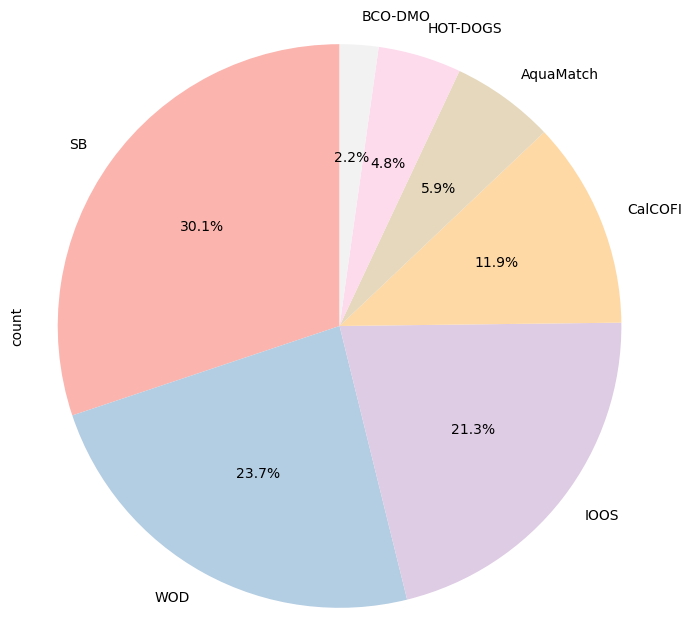

In [16]:
category_counts = all_chl['source'].value_counts()
plt.figure(figsize=(8, 8)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.axis('equal') 
plt.show()

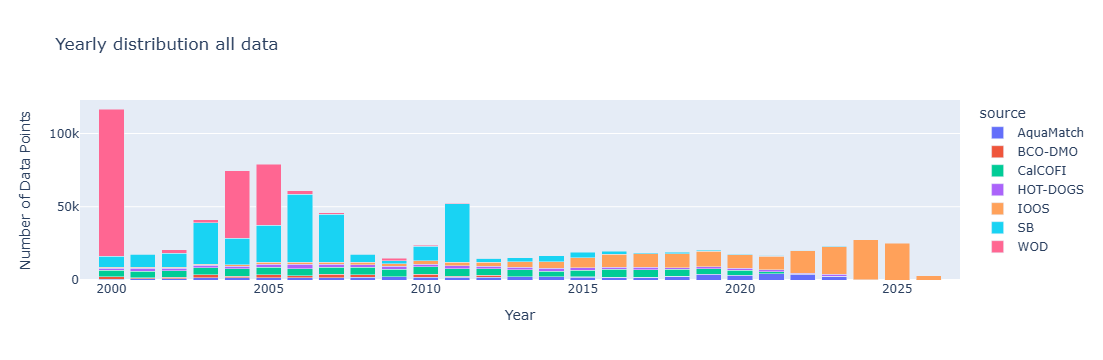

In [17]:
year_test=all_chl.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log10

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log10



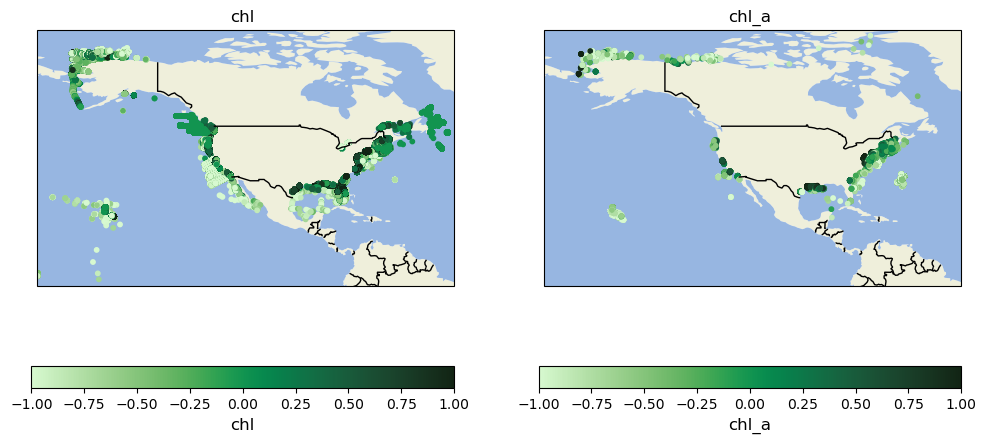

In [18]:
year_test['log_chl']=np.log10(year_test['chl'])
year_test['log_chl_a']=np.log10(year_test['chl_a'])

fig=plt.figure(figsize=(12, 7))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs1.set_title('chl')
axs1.set_xlim(min(all_chl.lon)-2,max(all_chl.lon)+2)
axs1.set_ylim(min(all_chl.lat)-2,max(all_chl.lat)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label('chl',fontsize=12)

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
im=axs2.scatter(year_test.lon,year_test.lat,c=year_test.log_chl_a,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs2.set_title('chl_a')
axs2.set_xlim(min(all_chl.lon)-2,max(all_chl.lon)+2)
axs2.set_ylim(min(all_chl.lat)-2,max(all_chl.lat)+2)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label('chl_a',fontsize=12)
#,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])}
#im=west_coastchl.plot(ax=axes[1],cmap='viridis',vmin=-1, vmax=1,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])})


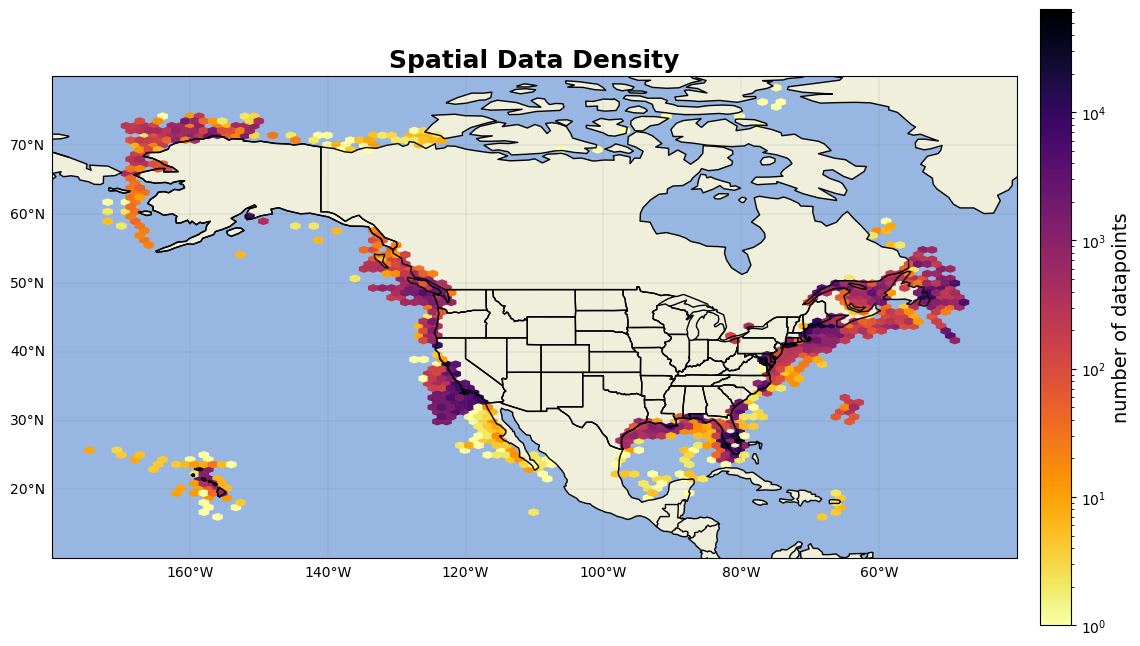

In [19]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=100, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# RRS

In [2]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
       'station', 'rrs', 'wavelength', 'depth']]
seabass['source']='SB'

In [3]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')
gloria['DOI_url'] = 'https://doi.pangaea.de/10.1594/PANGAEA.948492'
gloria['source']='GLORIA'

In [4]:
dfs=[seabass,gloria]
all_rrs = pd.concat(dfs).reset_index(drop=True)

In [5]:
all_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'rrs', 'wavelength',  'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 
            'cruise', 'station']
all_rrs = all_rrs.drop_duplicates(subset=all_vars, keep='first')
all_rrs['datetime'] = pd.to_datetime(all_rrs['datetime'])

In [84]:
#so these id tags will be different,, since there can be multiple rows with identical datetime, lon, lat, and depth but unique wavelength
#what i should do i think it first turn the dataframe into rrs_### and create id tags based on that and see what the value_counts is 

In [6]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 
               'affiliations', 'investigators', 'contact', 'cruise', 'station']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

test = long_to_wide(all_rrs)

In [7]:
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)

test['ID_code'] = (test['source'].astype(str) + '_' + test['temp_exp'].astype(str) + '_' + test['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + 
    test['lat'].astype(str) + '_' + test['lon'].astype(str) + '_' + test['depth'].astype(str) + 'm')
test['ID_code'] = test['ID_code'] + '_' + test.groupby('ID_code').cumcount().astype(str)

In [ ]:
#sometimes there are duplicates/ repeated data that have different rrs values. so add an id tag to THESE and then 
#turn back into long format df, that way these 3 ids will repeat for 9 rows, but they'll all relate to the same datetime lat lon ect without a unique code
#per wavelength value. 
#test2=test[(test['experiment']=='Bold_EPAHypoxia') & (test.lat ==29.532833)]
#test2.to_excel('test2.xlsx', index = False)

In [14]:
#turn back into rrs column adn wavelength column
rrs_cols = [col for col in test.columns if col.startswith('rrs_')]
id_vars_melt = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station', 'ID_code']

df_long = test.melt(id_vars=id_vars_melt, value_vars=rrs_cols,var_name='raw_wavelength',value_name='rrs')
df_long['raw_wavelength'] = df_long['raw_wavelength'].str.replace('rrs_', '')
df_long['wavelength'] = pd.to_numeric(df_long['raw_wavelength'])
df_long = df_long.drop(columns=['raw_wavelength'])
df_long = df_long.dropna(subset=['rrs'])
df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)
df_long=df_long.reset_index(drop=True)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_19128\1789082941.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)


In [15]:
print(len(df_long))
print(len(all_rrs))

796158
796158


In [12]:
#a=df_long.ID_code
#a.to_csv('rrs_ids.txt', index=False, header=False, sep='\n')

In [17]:
df_long.to_excel('all_rrs.xlsx', index = False)


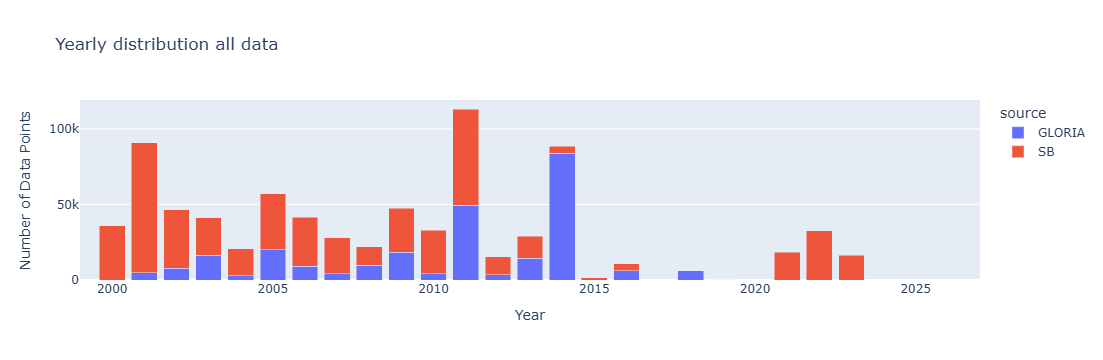

In [18]:
year_test=df_long.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

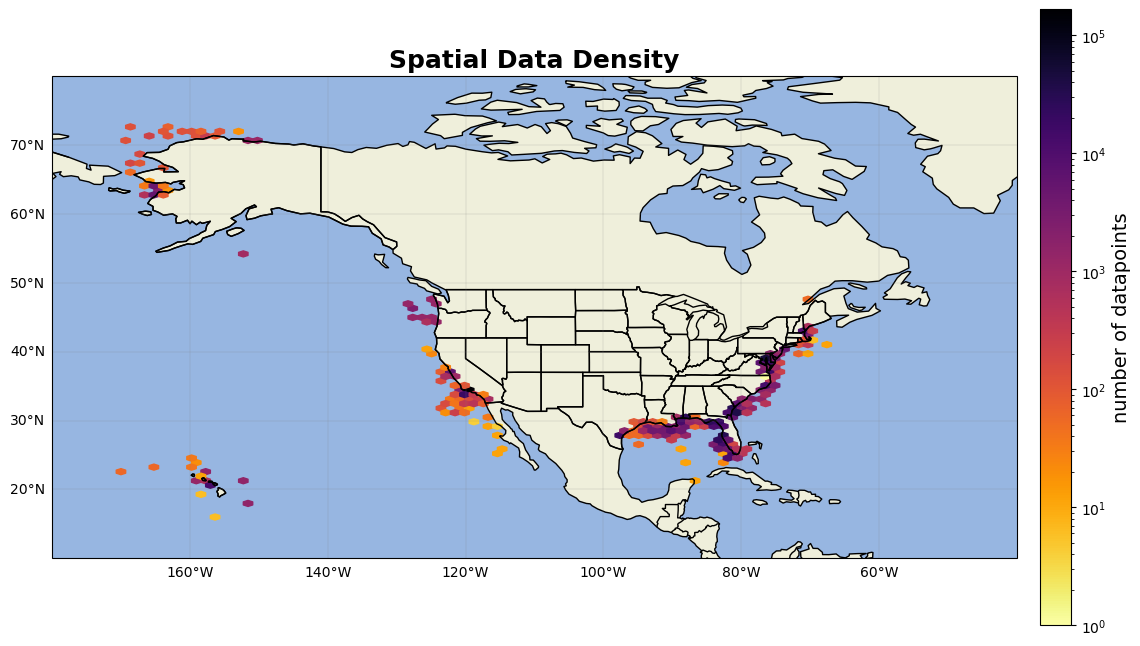

In [19]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(df_long.lon, df_long.lat, gridsize=75, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# CDOM

In [41]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations','investigators', 'experiment', 'cruise', 'station', 'depth','cdom']]
seabass['source']='SB'

In [42]:
ioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')
ioos = ioos.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','Dataset ID':'station'})
ioos=ioos[['datetime', 'lat', 'lon',  'cdom', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment','station']]

In [43]:
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')
bcodmo = bcodmo.rename(columns={'url':'DOI_url'})
bcodmo=bcodmo[['datetime', 'lat', 'lon', 'depth', 'cruise', 'cdom', 'experiment', 'source', 'investigators', 'affiliations', 'DOI_url',
       'station']]

In [45]:
dfs=[seabass,ioos,bcodmo]
all_cdom = pd.concat(dfs).reset_index(drop=True)
all_cdom = all_cdom.dropna(subset=['cdom'])
all_cdom = all_cdom.drop_duplicates()

In [2]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_cdom['temp_exp'] = all_cdom['experiment'].str.replace('_', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('-', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(' ', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('(', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(')', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('[', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(']', '', regex=False)

NameError: name 'all_cdom' is not defined

In [50]:
all_cdom['ID_code'] = all_cdom['source'].astype(str) + '_' + all_cdom['temp_exp'].astype(str) + '_' + all_cdom['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_cdom['lat'].astype(str) + '_' + all_cdom['lon'].astype(str) +'_' + all_cdom['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_cdom['ID_code'] = all_cdom['ID_code'] + '_' + all_cdom.groupby('ID_code').cumcount().astype(str)

In [54]:
#a=all_cdom.ID_code
#a.to_csv('cdom_ids.txt', index=False, header=False, sep='\n')

In [56]:
all_cdom=all_cdom[['datetime','lon','lat','depth','cdom','DOI_url','affiliations','investigators','experiment', 'cruise', 'station', 'source','ID_code']]

In [57]:
all_cdom.to_excel('all_cdom.xlsx', index = False)


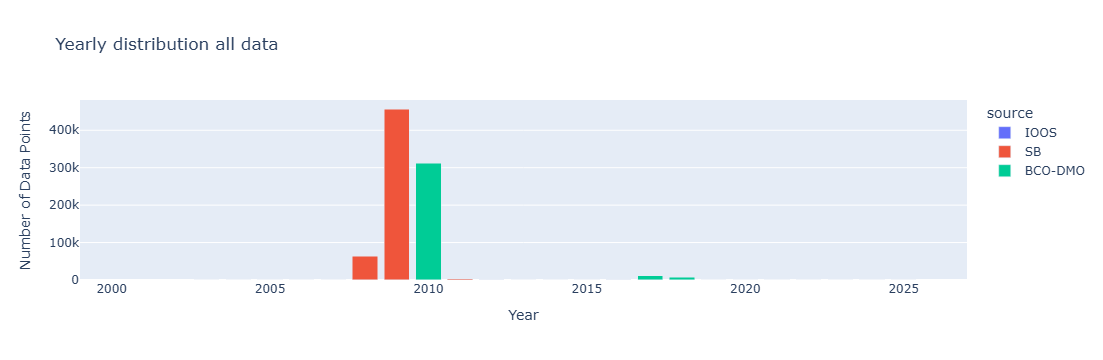

In [58]:
year_test=all_cdom.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

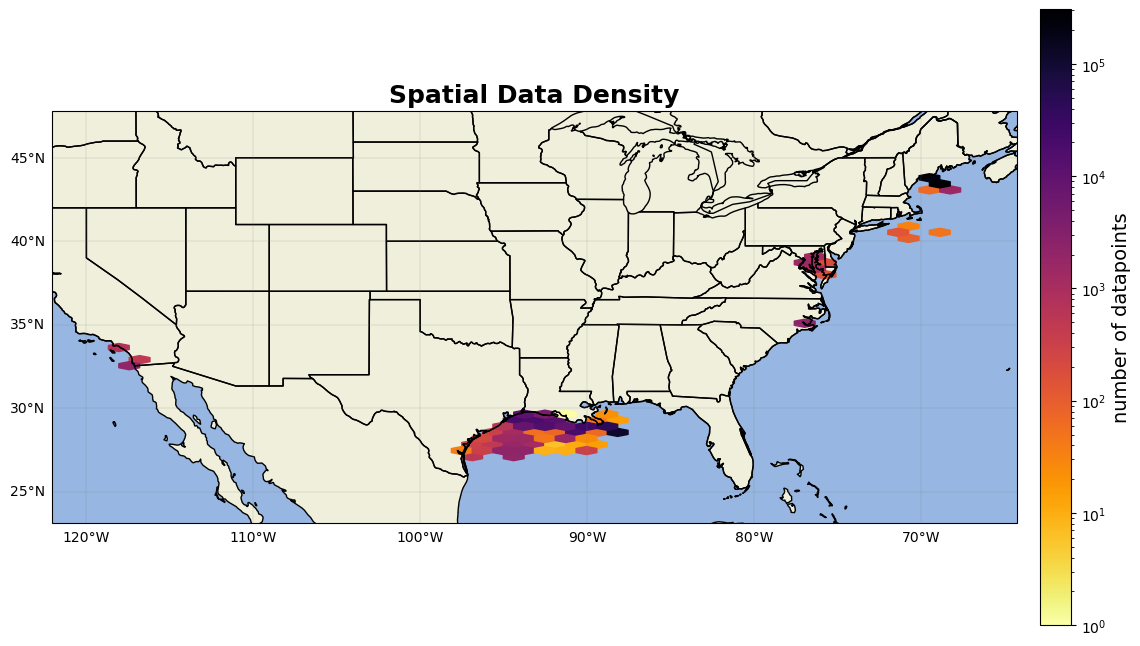

In [71]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(all_cdom.lon, all_cdom.lat, gridsize=40, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(all_cdom.lon)-4,max(all_cdom.lon)+4)
ax.set_ylim(min(all_cdom.lat)-4,max(all_cdom.lat)+4)
ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# concat onto 1 dataframe

In [2]:
#load in all completed dataframes
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

In [3]:
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')

In [4]:
rrs = rrs[rrs['wavelength'] <=800].reset_index(drop=True) #reduce to more realistic limit of wavelengths

In [5]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

In [6]:
#first, turn rrs data long format so that there is 1 uinique id for each row / group of wavelengths
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url','affiliations', 'investigators', 'contact', 'cruise', 'station',
               'ID_code']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs_long = long_to_wide(rrs)

In [ ]:
#ok, now to merge the three dataframes together
#for this, i want 2 different final dataframes. one will be only the points that match with the cholorophyll dataset (so for example, if on June 1st 2024
#only cdom was recorded not chl, this isn;t in the dataframe
#the second will be all data together, where if it's incidental it's matching but otherwise it not added 

In [7]:
#for only coincidental with chl, reduce the rrs and cdom data to just the variables + id 
cdom_reduced = cdom[['cdom', 'ID_code']]
rrs_cols = [col for col in rrs_long.columns if col.startswith('rrs_')]
rrs_reduced = rrs_long[rrs_cols+['ID_code']]

In [8]:
alldata_chl = pd.merge(chl, cdom_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')
#filtered_df = df_merged[df_merged['chl'].notna() & df_merged['cdom'].notna()] 

In [9]:
alldata_chl = pd.merge(alldata_chl, rrs_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')

In [10]:
print(alldata_chl.columns[:25])

Index(['ID_code', 'datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth',
       'experiment', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source',
       'cast', 'cdom', 'rrs_305', 'rrs_320', 'rrs_325', 'rrs_326', 'rrs_327'],
      dtype='object')


In [11]:
#alldata_chl.to_excel('compiled_chl_variables.xlsx', index = False) #all chlorophyll data with coincidental rrs and cdom data
filename = "compiled_chl_variables.csv.gz"
alldata_chl.to_csv(filename, index=False, compression='gzip')